In [26]:
"""------------------------------------------------------
 File Name: ToughApprox.py
 Goal: Find a function hard to approximate with a SNN
 Author: Francesca Cannata
---------------------------------------------------------"""
import argparse
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import matplotlib.pyplot as plt
import numpy as np
import math
import copy

In [160]:
# Read config from command line argument
parser = argparse.ArgumentParser(description='Training the network with different settings.')
parser.add_argument('--seed', type=int, default=0, help='Random seed (default: 0).')
parser.add_argument('--lr', type=float, default=0.01, help='Initial learning rate (default: 0.01)-')
parser.add_argument('--epochs', type=int, default=100, help='Number of epochs (default: 100).')
parser.add_argument('--units', type=int, default=10, help='Numbers of hidden neurons (default: 10).')

args = parser.parse_args() # Convert argument strings to objects and assign them as attributes of the namespace
print(f'This is the network\'s setting. \n Seed = {args.seed} \n Initial learning rate = {args.lr} \n Number of epochs = {args.epochs} \n Number of hidden neurons = {args.units}')

usage: ipykernel_launcher.py [-h] [--seed SEED] [--lr LR] [--epochs EPOCHS]
                             [--units UNITS]
ipykernel_launcher.py: error: unrecognized arguments: -f /var/folders/cy/s2chkgm94jggwgw6f17jdfnw0000gn/T/kernel-fe004a4f-6fe8-4287-9b92-3346d3cd19087262277784197770864/connection.json --IPCompleter.use_jedi=False --IPKernelApp.log_level=INFO


SystemExit: 2

/Users/francesca/Library/Mobile Documents/com~apple~CloudDocs/Master Thesis/Code/files/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


The barron norm is 4.227148701470277. 
 The normalized L2 norm is 1.0


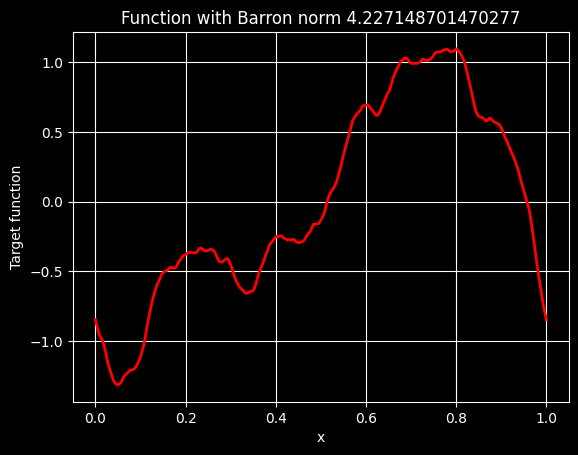

In [31]:
"""------------------------------------------
 Goal: Create a function hard to approximate
       with two frequency components
---------------------------------------------"""
# In order to have the same random generation each time (both in numpy and pytorch)
np.random.seed(0)
torch.manual_seed(0)

# Parameters
N = 2**10
n = int(N/2)
alpha = 1
beta = 2.1                                              # beta > 2 for having a finite Barron norm
omega = np.arange(1, n+1)                   # low and high frequencies
phi = np.random.uniform(0, 2*math.pi, size=n)      # phase shift
w = 1+np.abs(omega)                                     # weight function
c = alpha / w**beta                                     # ansatz for the amplitude


# Evaluate the Barron norm (p = 1)
barron_norm = np.sum(w * np.abs(c))

# Evaluate the L2 norm
L2_norm = np.sum(np.square(c))

# Normalize the L2 norm -> \sum_{i = 1}^{n} |c_i| = 1 => \alpha_{norm} = 1 / np.sqrt(np.sum(np.square(1.0 / (w ** beta))))
alpha_norm = 1 / np.sqrt(np.sum(np.square(1.0 / (w ** beta))))
c_normalized = alpha_norm / w**beta
L2_norm_normalized = np.sum(np.square(c_normalized))

# Print the norms
print(f'The barron norm is {barron_norm}. \n The normalized L2 norm is {L2_norm_normalized}')


# Spatial domain
x = torch.linspace(0,1,N).view(-1, 1).float()

# Numpy Array -> torch tensor
omega_tensor =  torch.from_numpy(omega).view(1, -1)
phi_tensor = torch.from_numpy(phi).view(1, -1)
c_tensor = torch.from_numpy(c_normalized).view(1, -1)

# Create the target function that we want to approximate
y = torch.sum(c_tensor * torch.sin(2*math.pi*omega_tensor*x + phi_tensor), dim=1).float()


# Visualization
fig = plt.figure(1)
plt.plot(x, y, color='red', linewidth=2)
plt.title(f'Function with Barron norm {barron_norm}')
plt.xlabel('x')
plt.ylabel('Target function')
plt.grid(True)


The current epoch is 1/100. The loss is:  0.8665762543678284
The current epoch is 100/100. The loss is:  0.1919786036014557
The best model is OrderedDict({'InHid1.weight': tensor([[-0.9411],
        [ 1.0467],
        [-0.9835],
        [-1.0814],
        [ 0.9530],
        [ 1.0239],
        [ 0.9493],
        [-0.8784],
        [-1.0659],
        [-1.0000],
        [ 1.0630],
        [ 0.9515],
        [-1.0000],
        [-1.0547],
        [ 1.0725],
        [-1.0000],
        [-0.8941],
        [ 1.0217],
        [-1.0658],
        [ 0.9507],
        [-0.9589],
        [ 1.0621],
        [-1.0000],
        [ 1.0604],
        [-1.0000],
        [-1.0000],
        [ 0.9674],
        [ 1.0666],
        [-1.0755],
        [-1.0486],
        [ 1.0685],
        [-0.9596],
        [ 0.9710],
        [-1.0000],
        [-1.0547],
        [-1.0414],
        [ 0.9490],
        [ 0.9489],
        [-1.0000],
        [ 0.9504]]), 'InHid1.bias': tensor([ 0.8622, -0.1612,  0.6834,  0.9127,  0.4294

Text(0.5, 1.0, 'Evolution of Loss (log scale)')

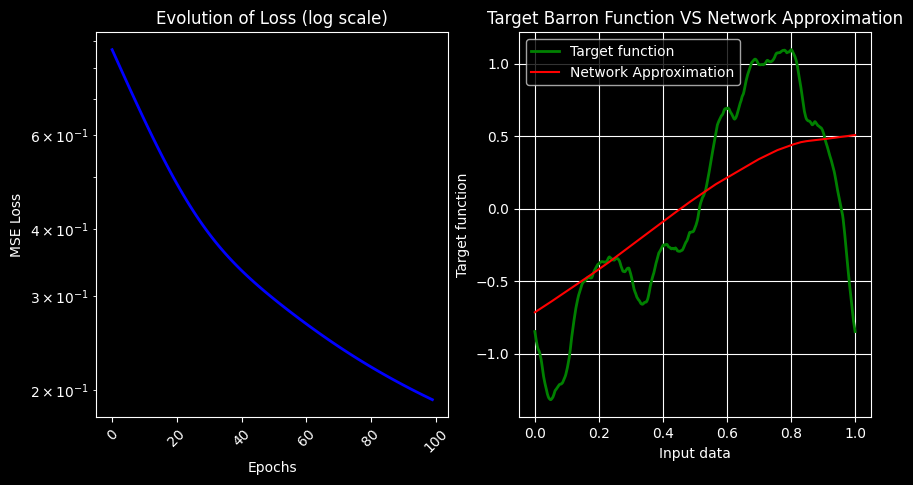

In [40]:

"""----------------------------------
 Goal: Build the SNN and train it
-------------------------------------"""
# ---------- Network Architecture and Model Definition ----------
# Define the number of neurons for each layer
n_in = 1
n_Hid1 = 40
n_out = 1

# Set the initial learning rate
learning_rate = 0.001

# Define a class which contains our training model.
class NeuralNet(nn.Module): # our class "NeuralNet" inherits all methods and properties from the superclass nn.Module in PyTorch
    def __init__(self):
        super().__init__() # initialization of nn.Module

        # Architecture of our network: two hidden layers with 2 and 3 neurons respectively and ReLU activation.
        # The function "nn.Linear(in_features, out_features)" applies an affine transformation to input data (x * W^T + b). It creates
        # the weight matrix of dimension (in_features, out_features) and the bias tensor of length in_features; it fills them with
        # random values. The bias argument is optional: by default is True, but one can disable it
        self.InHid1 = nn.Linear(n_in, n_Hid1)       # it creates the input-weight matrix with shape (n_in, n_Hid1) and the input-bias vector with size n_in
        self.Hid1Out = nn.Linear(n_Hid1, n_out)     # it creates the output-weight matrix with shape (n_Hid1, n_out) and the output-bias vector with size n_Hid1
        self.activation = nn.ReLU()                 # examples of non-linear activation functions: nn.ReLU(), nn.Tanh(), nn.Sigmoid(), nn.ELU() etc.

    # We need a function for establishing the order in which our data go through the layers
    # and for turning the input to the network (x) to its output
    def forward(self, x):
        x = self.activation(self.InHid1(x)) # input -> 1st Hidden: 1. With "self.InHid1(x)" each input x is multiplied by the input-weight and added to
                                            #                         the input-bias.
                                            #                      2. With "self.activation()", the net is applying the activation function to the result of
                                            #                         the previous step. They will get the new input x for the 1st-hidden layer.
        x = self.Hid1Out(x) # 2st Hidden -> output
        return x

# Define the model
model = NeuralNet()

# Create the loss function (we are taking the Mean Square Error MSE).
error = nn.MSELoss()

# Create the optimizer: it changes the "model.parameters()" (== the parameters of the network)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Change the learning rate dynamically with the Scheduler algorithm: we want to adjust it during the training
# Step Decay
scheduler = lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.3) # if we are not using it, uncomment also the lower bound for the learning rate in the for loop

# ReduceLROnPlateau
#scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=args.gamma, patience=500, min_lr=1e-5)


# Parameter's initialization
with torch.no_grad():
    # Bias
    nn.init.uniform_(model.InHid1.bias, a=-1, b=1)
    #print(f'Initialized bias: {model.InHid1.bias}')

    # Weight -> random +-1 value
    init_weights = torch.where(model.InHid1.weight <= 0, -1, 1)
    #print(init_weights)
    model.InHid1.weight.copy_(init_weights)
    #print(f'Initialized weight: {model.InHid1.weight}')


# ---------- Training Loop ----------
min_loss = float('inf') # initialization of the minimum loss at infinity
min_epoch = 0           # initialization of the epoch corresponding to the minimum loss
best_model = {}         # initialization of the dictionary which will contain the best model

epochs = 100
loss_history = np.zeros(epochs) # initialization of the array which will contain all errors
learning_rate_history = np.zeros(epochs) # initialization of the array which will contain all learning rates
for epoch in range(epochs):

    # Reset gradients in order to not accumulate them in the .grad attribute during next epochs
    optimizer.zero_grad()

    # Forward pass: compute predicted output y_pred passing the input data x_tensor to our model
    y_pred = model(x)

    # Compare the prediction y_pred to the target y_tensor evaluating the loss. We want it goes near to zero as much as possible
    loss = error(y_pred, y.view(-1,1))
    # print(f"For epoch ", epoch, " the loss is: ", loss.item())    # "loss.item()" gives us just the number inside the tensor.
                                                                    # Otherwise, if we print "loss", we will see the number and its derivation


    # Backward pass: determine how much each parameter contribute to the error. To this end, we compute the
    # derivatives of the error function with respect to every model parameter. It starts from the back to the start.
    # It stores the result for each parameter in their ".grad()" attribute
    loss.backward()

    # Gradient descent: update the parameters in the direction stored in .grad() attribute
    optimizer.step()

    # Update the learning rate when reaching the "step_size" and when it is grater than or equal to 10^-5 (lower bound)
    if scheduler.get_last_lr()[0] > 10**(-5):   # scheduler.get_last_lr()[0] get the most recent learning rates computed by the scheduler.
        scheduler.step()

    # Update the learning rate with Plateau scheduler
    #scheduler.step()

    # Keep track of the minimum loss, its epoch and the corresponding model
    aux_loss = loss.item() # auxiliary array with the epoch and the corresponding loss
    if loss.item() < min_loss:
        min_loss = loss.item()
        min_epoch = epoch

        best_model = copy.deepcopy(model.state_dict())      # in order to have a copy (and not a reference) we need to use "copy.deepcopy()"

    # Let us create a plot which compare y_pred and y_tensor for the first epoch and then every 100 epochs
    if epoch == 0 or (epoch + 1) % 100 == 0:     # epoch + 1 is needed because the counting starts from 0
        # Print the epoch and the corresponding loss
        print(f"The current epoch is {(epoch+1)}/{epochs}. The loss is: ", loss.item())

    # add the loss to the array
    loss_history[epoch] = loss.item()
    learning_rate_history[epoch] = scheduler.get_last_lr()[0]


# To be sure the net uses the best model found, we load it with "model.load_state_dict()" and save it
model.load_state_dict(best_model)
print(f"The best model is {best_model}")

# We want to have the same size for bias and weights using .flatten()
bias_InHid1 = best_model["InHid1.bias"].flatten().numpy()
bias_Hid1Out = best_model["Hid1Out.bias"].flatten().numpy()
weight_InHid1 = best_model["InHid1.weight"].flatten().numpy()
weight_Hid1Out = best_model["Hid1Out.weight"].flatten().numpy()

best_model_dataframe = pd.DataFrame({'Bias_Intput_Layer': pd.Series(bias_InHid1),
                            'Weights_Intput_Layer': pd.Series(weight_InHid1),
                            'Bias_Output_Layer': pd.Series(bias_Hid1Out),
                            'Weights_Output_Layer': pd.Series(weight_Hid1Out)})

print(best_model_dataframe)


# ---------- Visualization ----------
# Compute the prediction corresponding to the last epoch, without Autograd tracking
with torch.no_grad(): # all commands in here, will be without attribute "grad_fn"
    y_pred_final = model(x).numpy() # we are converting the tensor to a numpy array just for making the plot

# Print the final epoch with the corresponding loss
print(f"The final epoch is {(epoch+1)}/{epochs} and the loss is {(loss.item())}")

# Print the minimum loss and its epoch
print(f"The minimum loss is {(min_loss)} and its epoch is {(min_epoch+1)}")

# Final plot
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[1].plot(x, y, label='Target function', color='green', linewidth=2)
ax[1].plot(x, y_pred_final, label='Network Approximation', color='red')

# Plots attributes
ax[1].set_xlabel('Input data')
ax[1].set_ylabel('Target function')
ax[1].set_title('Target Barron Function VS Network Approximation')
ax[1].legend(loc='best')
ax[1].grid(True)

ax[0].semilogy(loss_history, label='Training Loss', color='blue', linewidth=2)
ax[0].set_xlabel('Epochs')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_ylabel('MSE Loss')
ax[0].set_title('Evolution of Loss (log scale)')

#os.makedirs(f'results_InitLR_{args.lr}_StepSize_{args.stepsize}', exist_ok=True) # it creates a new folder
#plt.savefig(os.path.join(f'results_InitLR_{args.lr}_StepSize_{args.stepsize}', f'LossApprox_Epochs_{args.epochs}_HidNeurons_{args.units}.png'))
#plt.clf() # clear fig
#plt.close() # close fig

# Create a dataframe with the epochs, the loss_history and the learning rate and save it
#history_dataframe = pd.DataFrame({'Epoch': np.arange(args.epochs),
                           # 'Loss Value': loss_history,
                            #'Learning Rate': learning_rate_history})
#history_dataframe.to_csv(os.path.join(f'results_InitLR_{args.lr}_StepSize_{args.stepsize}', f'History_Epochs_{args.epochs}_HidNeurons_{args.units}.csv'), index=False)



#best_model_dataframe.to_csv(os.path.join(f'results_InitLR_{0.001}_StepSize_{5000}', f'BestModel_Epochs_{n}_HidNeurons_{n}.csv'), index=False)

In [155]:
"""------------------
Goal: Visualizations
---------------------"""

# Position of activated neurons:  0 = y = weight * x + bias =>  x = - bias/weight
zero_pos = -model.InHid1.bias.flatten()/model.InHid1.weight.flatten()

# Select the activated neurons whose position is between -1 and 1
pos_in_range = torch.bitwise_and(zero_pos >= -1.0, zero_pos <= 1.0)

# Select the weights associate to the activated neurons
weight_in_range = model.Hid1Out.weight.flatten()[pos_in_range]

# Plot of activated weights
plt.figure(1)
plt.hist(weight_in_range.detach().numpy(), bins=50, color='blue', alpha=0.5, label='Weight')
plt.savefig(os.path.join('results', f'ActiveWeights_Epochs_{args.epochs}_HidNeurons_{args.units}.png'))
plt.clf()
plt.close()

# Plot of activated neurons
plt.figure(2)
plt.stem(zero_pos[pos_in_range].detach(), weight_in_range.detach(), label='Weight')
plt.savefig(os.path.join('results', f'ActiveNeurons_Epochs_{args.epochs}_HidNeurons_{args.units}.png'))
plt.clf()
plt.close()

# Print how many neurons are activated between -1 and 1
print(f'{torch.sum(pos_in_range)} are inside the range')
